In [1]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")

%cd /content
!git clone https://{GITHUB_TOKEN}@github.com/Bassey-data/Auto-insurance-claim-frequency.git

%cd /content/Auto-insurance-claim-frequency
!git config user.email "basseysamuel404@gmail.com"
!git config user.name "Bassey-data"

print("Setup complete")

/content
Cloning into 'Auto-insurance-claim-frequency'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 25 (delta 7), reused 18 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 65.15 KiB | 612.00 KiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/Auto-insurance-claim-frequency
Setup complete


In [2]:
pip install statsmodels liac-arff lightgbm pyarrow shap

  Preparing metadata (setup.py) ... done
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=2d73cc08a0e372f4b5aa1b78e629fc5e1ca63789d9a8f3840e146a6c01b8fa1b
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


Import all useful modules

In [3]:

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
warnings.filterwarnings("ignore")


In [4]:
# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

In [5]:
def parse_arff(path):
    columns = []
    data_start = None

    with open(path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.lower().startswith("@attribute"):
            parts = stripped.split(maxsplit=2)
            columns.append(parts[1])
        elif stripped.lower().startswith("@data"):
            data_start = i + 1
            break

    data_lines = [l.strip() for l in lines[data_start:] if l.strip()]

    rows = []
    for line in data_lines:
        values = [v.strip().strip("'").strip('"') for v in line.split(",")]
        rows.append(values)

    return pd.DataFrame(rows, columns=columns)


df = parse_arff("/content/drive/MyDrive/ACQsci.arff")

print(df.head())

  IDpol ClaimNb Exposure Area VehPower VehAge DrivAge BonusMalus VehBrand  \
0     1       1      0.1    D        5      0      55         50      B12   
1     3       1     0.77    D        5      0      55         50      B12   
2     5       1     0.75    B        6      2      52         50      B12   
3    10       1     0.09    B        7      0      46         50      B12   
4    11       1     0.84    B        7      0      46         50      B12   

    VehGas Density Region  
0  Regular    1217    R82  
1  Regular    1217    R82  
2   Diesel      54    R22  
3   Diesel      76    R72  
4   Diesel      76    R72  


In [6]:
df.dtypes

,0
IDpol,object
ClaimNb,object
Exposure,object
Area,object
VehPower,object
VehAge,object
DrivAge,object
BonusMalus,object
VehBrand,object
VehGas,object


fix numeric and categorical columns data types

In [7]:
# used an f string for readable output
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isna().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Shape: (678013, 12)

Missing values:
IDpol         0
ClaimNb       0
Exposure      0
Area          0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Density       0
Region        0
dtype: int64

Duplicate rows: 0


In [8]:
df_converted = df.apply(pd.to_numeric, errors="ignore")

for col in df_converted.select_dtypes(include="object").columns:
    df_converted[col] = df_converted[col].astype("category")

df = df_converted
print(df.dtypes)

IDpol          float64
ClaimNb          int64
Exposure       float64
Area          category
VehPower         int64
VehAge           int64
DrivAge          int64
BonusMalus       int64
VehBrand      category
VehGas        category
Density          int64
Region        category
dtype: object


In [9]:
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isna().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Shape: (678013, 12)

Missing values:
IDpol         0
ClaimNb       0
Exposure      0
Area          0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Density       0
Region        0
dtype: int64

Duplicate rows: 0


Converting dataset to parquet

In [10]:
os.makedirs("data/processed", exist_ok=True)

df.to_parquet("data/processed/freMTPL2freq.parquet", index=False)

print("Saved successfully")
print(f"Parquet size: {os.path.getsize('data/processed/freMTPL2freq.parquet') / 1e6:.1f} MB")

Saved successfully
Parquet size: 7.5 MB


In [11]:
print(os.path.exists("/content/Auto-insurance-claim-frequency/data/processed/freMTPL2freq.parquet"))


True


In [12]:
%cd /content/Auto-insurance-claim-frequency

# Create notebooks folder and copy notebook into it
!mkdir -p notebooks
!cp "/content/drive/MyDrive/Colab Notebooks/Insurance_claim.ipynb" notebooks/01_data_prep.ipynb

# The parquet is gitignored which is correct - data files shouldn't be on GitHub
# Let's confirm notebooks got copied
!ls notebooks/

/content/Auto-insurance-claim-frequency
01_data_prep.ipynb


In [13]:
df = pd.read_parquet("/content/Auto-insurance-claim-frequency/data/processed/freMTPL2freq.parquet")
print(df.shape)
print(df.head())

(678013, 12)
   IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  \
0    1.0        1      0.10    D         5       0       55          50   
1    3.0        1      0.77    D         5       0       55          50   
2    5.0        1      0.75    B         6       2       52          50   
3   10.0        1      0.09    B         7       0       46          50   
4   11.0        1      0.84    B         7       0       46          50   

  VehBrand   VehGas  Density Region  
0      B12  Regular     1217    R82  
1      B12  Regular     1217    R82  
2      B12   Diesel       54    R22  
3      B12   Diesel       76    R72  
4      B12   Diesel       76    R72  


Check total clims and total exposure and calculate portfolio frequency

In [14]:
total_claims = df["ClaimNb"].sum()
total_exposure = df["Exposure"].sum()
portfolio_frequency = total_claims / total_exposure

print(f"Total claims: {total_claims:,}")
print(f"Total exposure (policy-years): {total_exposure:,.1f}")
print(f"Portfolio frequency: {portfolio_frequency:.4f} claims per policy-year")

Total claims: 36,102
Total exposure (policy-years): 358,499.4
Portfolio frequency: 0.1007 claims per policy-year


Check claim distribution

In [15]:
claim_counts = df["ClaimNb"].value_counts().sort_index()
print(claim_counts)
print()
print(f"Policies with zero claims: {(df['ClaimNb'] == 0).mean() * 100:.2f}%")

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

Policies with zero claims: 94.98%


Visualize using log scale

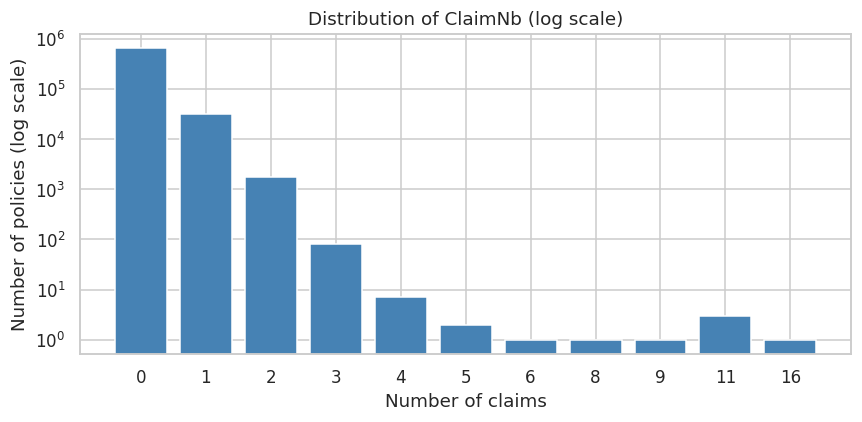

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(claim_counts.index.astype(str), claim_counts.values, color="steelblue")
ax.set_yscale("log")
ax.set_title("Distribution of ClaimNb (log scale)")
ax.set_xlabel("Number of claims")
ax.set_ylabel("Number of policies (log scale)")

plt.tight_layout()
plt.show()

Exposure plot

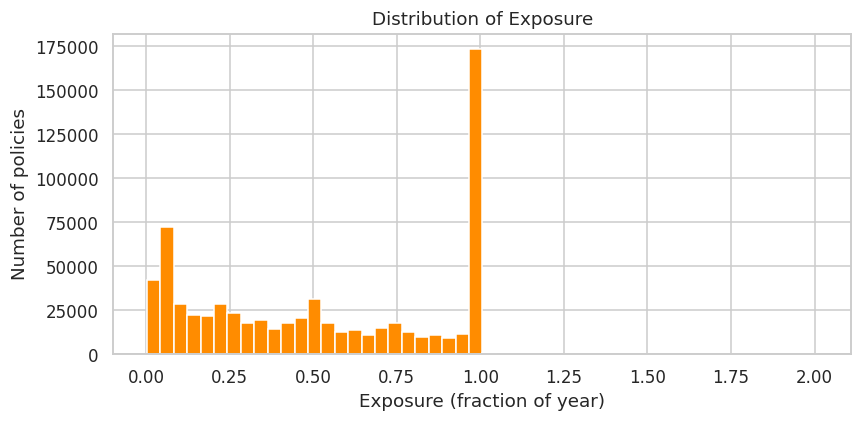

Min exposure: 0.0027322404371584
Max exposure: 2.01
Policies with Exposure > 1: 1224


In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df["Exposure"], bins=50, color="darkorange")
ax.set_title("Distribution of Exposure")
ax.set_xlabel("Exposure (fraction of year)")
ax.set_ylabel("Number of policies")

plt.tight_layout()
plt.show()

print(f"Min exposure: {df['Exposure'].min()}")
print(f"Max exposure: {df['Exposure'].max()}")
print(f"Policies with Exposure > 1: {(df['Exposure'] > 1).sum()}")

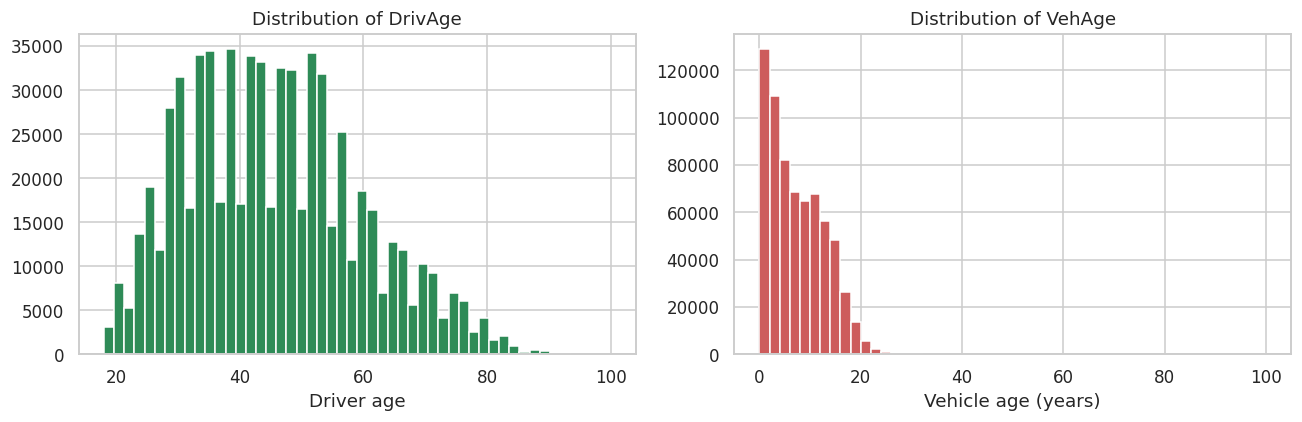

DrivAge range: 18 - 100
VehAge range: 0 - 100
Policies with VehAge > 30: 1116


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["DrivAge"], bins=50, color="seagreen")
axes[0].set_title("Distribution of DrivAge")
axes[0].set_xlabel("Driver age")

axes[1].hist(df["VehAge"], bins=50, color="indianred")
axes[1].set_title("Distribution of VehAge")
axes[1].set_xlabel("Vehicle age (years)")

plt.tight_layout()
plt.show()

print(f"DrivAge range: {df['DrivAge'].min()} - {df['DrivAge'].max()}")
print(f"VehAge range: {df['VehAge'].min()} - {df['VehAge'].max()}")
print(f"Policies with VehAge > 30: {(df['VehAge'] > 30).sum()}")

In [19]:
def exposure_weighted_frequency(df, group_col):
    # Group by the column and sum claims and exposure separately
    g = df.groupby(group_col, observed=True).agg(
        claims=("ClaimNb", "sum"),    # total claims in this group
        exposure=("Exposure", "sum")  # total exposure in this group
    )

    # Divide total claims by total exposure to get the true rate
    # This is correct - NOT the mean of (ClaimNb/Exposure) per policy
    g["frequency"] = g["claims"] / g["exposure"]

    return g.sort_index()

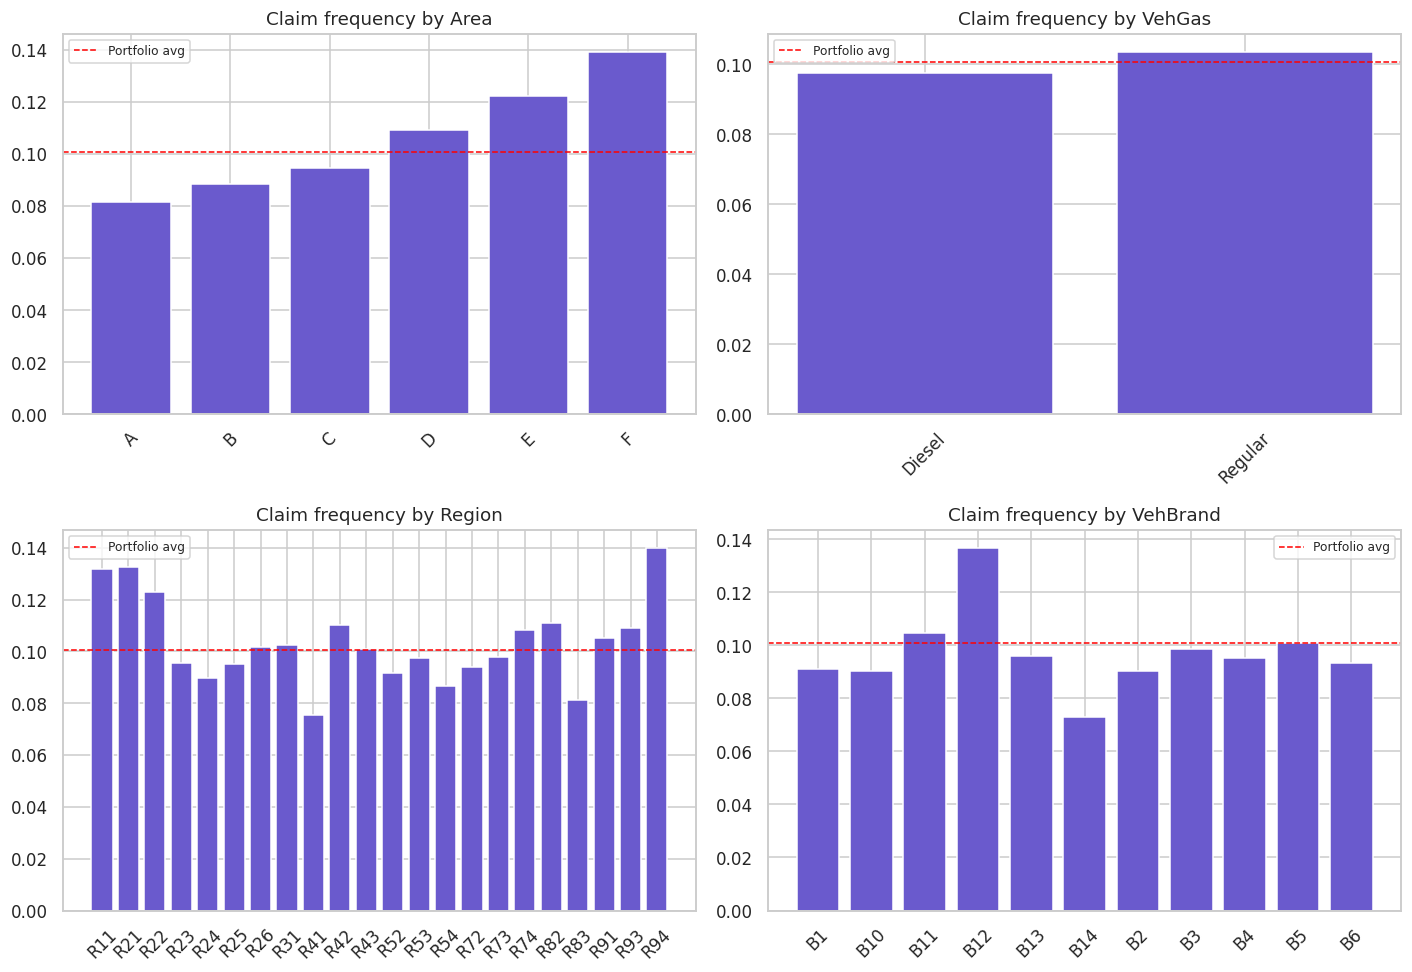

In [20]:
# Plot frequency by each categorical feature
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

cat_cols = ["Area", "VehGas", "Region", "VehBrand"]

for ax, col in zip(axes.flat, cat_cols):
    # Get exposure-weighted frequency for this column
    freq_table = exposure_weighted_frequency(df, col)

    # Plot as bar chart
    ax.bar(freq_table.index.astype(str), freq_table["frequency"], color="slateblue")

    # Add a red dashed line at the portfolio average so we can see above/below average groups
    ax.axhline(portfolio_frequency, color="red", linestyle="--", linewidth=1, label="Portfolio avg")

    ax.set_title(f"Claim frequency by {col}")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

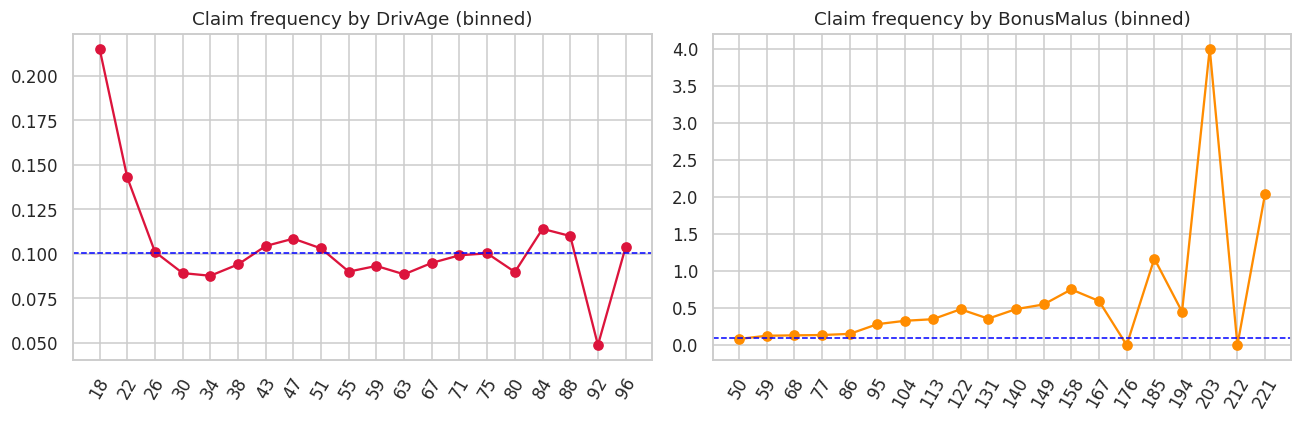

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bin DrivAge into 20 groups and plot frequency per bin
df["DrivAge_bin"] = pd.cut(df["DrivAge"], bins=20)
freq_age = exposure_weighted_frequency(df, "DrivAge_bin")
x_labels = [f"{i.left:.0f}" for i in freq_age.index]
axes[0].plot(x_labels, freq_age["frequency"], marker="o", color="crimson")
axes[0].set_title("Claim frequency by DrivAge (binned)")
axes[0].tick_params(axis="x", rotation=60)
axes[0].axhline(portfolio_frequency, color="blue", linestyle="--", linewidth=1)

# Same for BonusMalus
df["BonusMalus_bin"] = pd.cut(df["BonusMalus"], bins=20)
freq_bm = exposure_weighted_frequency(df, "BonusMalus_bin")
x_labels_bm = [f"{i.left:.0f}" for i in freq_bm.index]
axes[1].plot(x_labels_bm, freq_bm["frequency"], marker="o", color="darkorange")
axes[1].set_title("Claim frequency by BonusMalus (binned)")
axes[1].tick_params(axis="x", rotation=60)
axes[1].axhline(portfolio_frequency, color="blue", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

In [22]:
# Drop the temporary binning columns we created for plotting
df = df.drop(columns=["DrivAge_bin", "BonusMalus_bin"])

print(df.columns.tolist())

['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region']


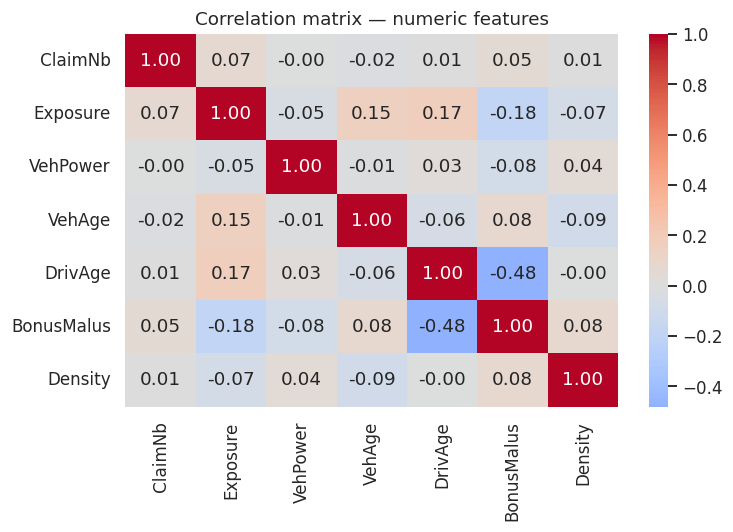

In [23]:
# Select only numeric columns for correlation analysis
numeric_cols = ["ClaimNb", "Exposure", "VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]

# Compute correlation matrix
corr = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — numeric features")
plt.tight_layout()
plt.show()

In [25]:
# Load the cleaned dataset from parquet
df = pd.read_parquet("/content/Auto-insurance-claim-frequency/data/processed/freMTPL2freq.parquet")

print(df.shape)

(678013, 12)


In [27]:
# Cap VehAge at 20 - values above this are almost certainly data errors
# This follows the convention used in actuarial literature for this dataset
df["VehAge"] = df["VehAge"].clip(upper=20)

# Cap Exposure at 1 - a policy cannot be active for more than a full year
df["Exposure"] = df["Exposure"].clip(upper=1)

# Cap ClaimNb at 4 - extreme values add noise without changing the risk story
# A policy with 5+ claims is treated the same as one with 4
df["ClaimNb"] = df["ClaimNb"].clip(upper=4)

# Confirm the caps worked
print(f"VehAge max: {df['VehAge'].max()}")
print(f"Exposure max: {df['Exposure'].max()}")
print(f"ClaimNb max: {df['ClaimNb'].max()}")

VehAge max: 20
Exposure max: 1.0
ClaimNb max: 4


In [28]:
# Area is ordered (A is lowest risk, F is highest) so encode as integer
# This preserves the ordering rather than treating each letter as unrelated categories
area_order = sorted(df["Area"].cat.categories)
area_map = {cat: i for i, cat in enumerate(area_order)}

df["Area_ord"] = df["Area"].map(area_map).astype(int)

print("Area encoding:", area_map)
print(df[["Area", "Area_ord"]].head(10))

Area encoding: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}
  Area  Area_ord
0    D         3
1    D         3
2    B         1
3    B         1
4    B         1
5    E         4
6    E         4
7    C         2
8    C         2
9    B         1


In [29]:
# Target and offset columns
target = "ClaimNb"
offset_col = "Exposure"

# Nominal categoricals - no natural order, need different treatment per model
nominal_cols = ["VehBrand", "VehGas", "Region"]

# Numeric features - used directly by both models
numeric_cols = ["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density", "Area_ord"]

# Combined feature list (excluding ID, target, offset)
feature_cols = numeric_cols + nominal_cols

print("Features:", feature_cols)
print("Target:", target)
print("Offset:", offset_col)

Features: ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area_ord', 'VehBrand', 'VehGas', 'Region']
Target: ClaimNb
Offset: Exposure


In [30]:
# Create a binary column to stratify on - ensures both sets have similar claim rates
# Without this, a random split could leave test set with an unrepresentative claim rate
df["had_claim"] = (df[target] > 0).astype(int)

# 80/20 split, stratified by whether a policy had any claim
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["had_claim"]
)

# Drop the temporary stratification column
train_df = train_df.drop(columns="had_claim")
test_df = test_df.drop(columns="had_claim")

print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")
print(f"Train portfolio frequency: {train_df[target].sum() / train_df[offset_col].sum():.4f}")
print(f"Test portfolio frequency:  {test_df[target].sum() / test_df[offset_col].sum():.4f}")

Train: (542410, 13)
Test: (135603, 13)
Train portfolio frequency: 0.1005
Test portfolio frequency:  0.1009


In [31]:
# --- GLM feature set ---
# Nominal categoricals need one-hot encoding for the GLM
# drop_first=True drops one category per feature to avoid the dummy variable trap
train_glm = pd.get_dummies(train_df, columns=nominal_cols, drop_first=True)
test_glm = pd.get_dummies(test_df, columns=nominal_cols, drop_first=True)

# Align columns - test set might be missing a rare category by chance
train_glm, test_glm = train_glm.align(test_glm, join="left", axis=1, fill_value=0)

# --- GBM feature set ---
# LightGBM handles categoricals natively - no one-hot needed
# Just ensure they are category dtype
train_gbm = train_df.copy()
test_gbm = test_df.copy()

for col in nominal_cols:
    train_gbm[col] = train_gbm[col].astype("category")
    test_gbm[col] = test_gbm[col].astype("category")

print(f"GLM feature columns: {[c for c in train_glm.columns if c not in ['IDpol', target, offset_col]]}")
print(f"\nGBM feature columns: {[c for c in train_gbm.columns if c not in ['IDpol', target, offset_col]]}")

GLM feature columns: ['Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area_ord', 'VehBrand_B10', 'VehBrand_B11', 'VehBrand_B12', 'VehBrand_B13', 'VehBrand_B14', 'VehBrand_B2', 'VehBrand_B3', 'VehBrand_B4', 'VehBrand_B5', 'VehBrand_B6', 'VehGas_Regular', 'Region_R21', 'Region_R22', 'Region_R23', 'Region_R24', 'Region_R25', 'Region_R26', 'Region_R31', 'Region_R41', 'Region_R42', 'Region_R43', 'Region_R52', 'Region_R53', 'Region_R54', 'Region_R72', 'Region_R73', 'Region_R74', 'Region_R82', 'Region_R83', 'Region_R91', 'Region_R93', 'Region_R94']

GBM feature columns: ['Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region', 'Area_ord']


In [32]:
# Drop original Area column since Area_ord replaces it
train_glm = train_glm.drop(columns="Area")
test_glm = test_glm.drop(columns="Area")

train_gbm = train_gbm.drop(columns="Area")
test_gbm = test_gbm.drop(columns="Area")

print("GLM columns:", len([c for c in train_glm.columns if c not in ["IDpol", target, offset_col]]))
print("GBM columns:", len([c for c in train_gbm.columns if c not in ["IDpol", target, offset_col]]))

GLM columns: 38
GBM columns: 9


In [33]:
# Save model-ready datasets to processed folder
train_glm.to_parquet("/content/Auto-insurance-claim-frequency/data/processed/train_glm.parquet", index=False)
test_glm.to_parquet("/content/Auto-insurance-claim-frequency/data/processed/test_glm.parquet", index=False)
train_gbm.to_parquet("/content/Auto-insurance-claim-frequency/data/processed/train_gbm.parquet", index=False)
test_gbm.to_parquet("/content/Auto-insurance-claim-frequency/data/processed/test_gbm.parquet", index=False)

print("Saved 4 files:")
print(f"  train_glm: {train_glm.shape}")
print(f"  test_glm:  {test_glm.shape}")
print(f"  train_gbm: {train_gbm.shape}")
print(f"  test_gbm:  {test_gbm.shape}")

Saved 4 files:
  train_glm: (542410, 41)
  test_glm:  (135603, 41)
  train_gbm: (542410, 12)
  test_gbm:  (135603, 12)
